In [1]:
# load necessary libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from transformers import BertTokenizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
import umap
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from collections import defaultdict
from pathlib import Path

#project_root = Path(__file__).resolve().parents[3]
project_root = Path.cwd() / "../"
sys.path.append(str(project_root))

from utils.clustering import (
    TripletDataset, TripletDatasetHN, ModelMask, ModelMaskHN,
    generate_triplets, generate_triplets_heuristic_hn, generate_triplets_hn,
    train_triplet, train_triplet_hn
)

# load the dictionary terms
groups_dictionary = pd.read_excel("../01_data/classification/dictionary/groups_dictionary_cl.xlsx")

In [2]:
# create a single list of all dictionary entries paired with their category
mention_list = []
category_list = []
categories = groups_dictionary.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dictionary[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry.strip())
            category_list.append(category)

category_list = [cat for cat in category_list]

df = pd.DataFrame({'mention': mention_list, 'category': category_list})

mention_list = df["mention"].to_list()
category_list = df["category"].to_list()

In [3]:
# custom list of semantically close groups to perform hard negative mining based on heuristic
close_groups = [("patients", "people with disabilities"), ("law-enforcement personnel", "military personnel"), ("men", "women"),
                ("upper class", "middle class"), ("crime victims", "criminals"), ("landlords", "homeowners and landowners", "tenants"),
                ("caregivers", "health professionals")]
close_map = defaultdict(list)
for group in close_groups:
    for c in group:
        close_map[c] = [x for x in group if x != c]

In [13]:
# train the model
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = ModelMask(tokenizer).to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.TripletMarginLoss(margin=1.0, p=2)
num_epochs = 25
for epoch in range(num_epochs):
    triplets = generate_triplets(df)
    dataset = TripletDataset(triplets, tokenizer)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
    loss = train_triplet(model, dataloader, loss_fn, optimizer, device)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Training: 100%|██████████| 23/23 [00:09<00:00,  2.42it/s]


Epoch 1, Loss: 0.7514


Training: 100%|██████████| 23/23 [00:08<00:00,  2.58it/s]


Epoch 2, Loss: 0.4644


Training: 100%|██████████| 23/23 [00:08<00:00,  2.62it/s]


...

Epoch 23, Loss: 0.0416


Training: 100%|██████████| 23/23 [00:08<00:00,  2.61it/s]


Epoch 24, Loss: 0.0353


Training: 100%|██████████| 23/23 [00:08<00:00,  2.60it/s]

Epoch 25, Loss: 0.0453


In [15]:
def get_mask_embedding(model, mentions, tokenizer, device, max_len=32, batch_size=32):

    model.eval()
    all_embeddings = []
    mask_token = tokenizer.mask_token

    with torch.no_grad():
        for start in range(0, len(mentions), batch_size):
            batch_mentions = mentions[start:start+batch_size]
            batch_texts = []
            for m in batch_mentions:
                text = f"Social group of {m} is: {mask_token}."
                batch_texts.append(text)
            
            enc = tokenizer(
                batch_texts,
                padding='max_length',
                truncation=True,
                max_length=max_len,
                return_tensors='pt'
            )

            input_ids = enc['input_ids'].to(device)
            attention_mask = enc['attention_mask'].to(device)

            z = model.encode(input_ids, attention_mask)

            all_embeddings.append(z.cpu())

    return torch.cat(all_embeddings, dim=0)

# load model from checkpoint
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = ModelMaskHN(tokenizer).to(device)
model.load_state_dict(torch.load(f="checkpoint.pt", map_location=torch.device("mps")))

mention_embeddings = get_mask_embedding(model, mention_list, tokenizer, device)
labels_np = np.array([cat2id[cat] for cat in category_list])

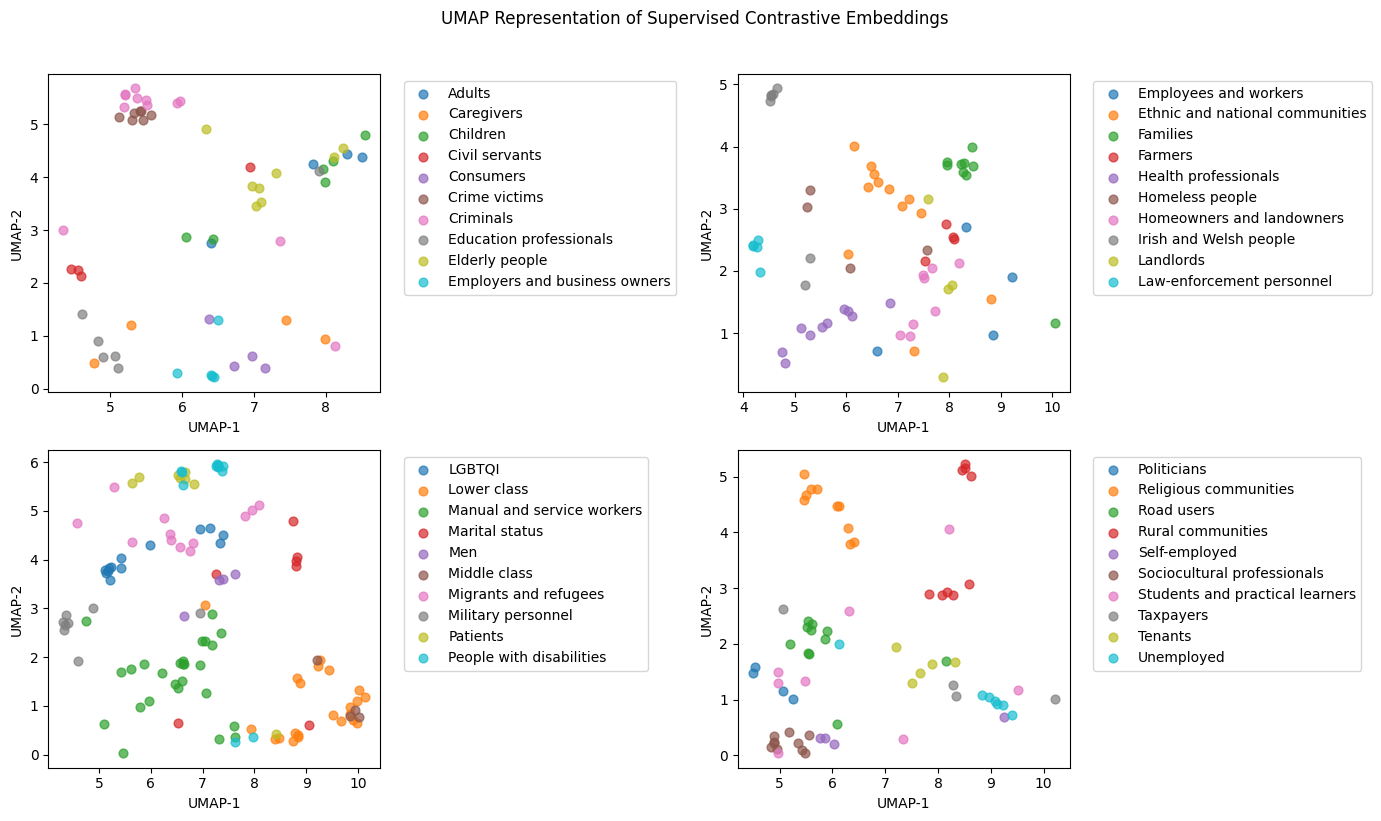

In [16]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = ModelMask(tokenizer).to(device)
emb_without_cl = get_mask_embedding(model, mention_list, tokenizer, device)


reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(emb_without_cl)

categories = list(cat2id.keys())
num_classes = len(categories)

groups = [
    range(0, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, group in zip(axes, groups):
    for c in group:
        if c >= num_classes:
            continue
        idx = np.where(labels_np == c)[0]
        if len(idx) == 0:
            continue
        ax.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            label=categories[c],
            alpha=0.7,
            s=40
        )
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

fig.suptitle("UMAP Representation of Supervised Contrastive Embeddings", y=1.02)
plt.tight_layout()
plt.show()

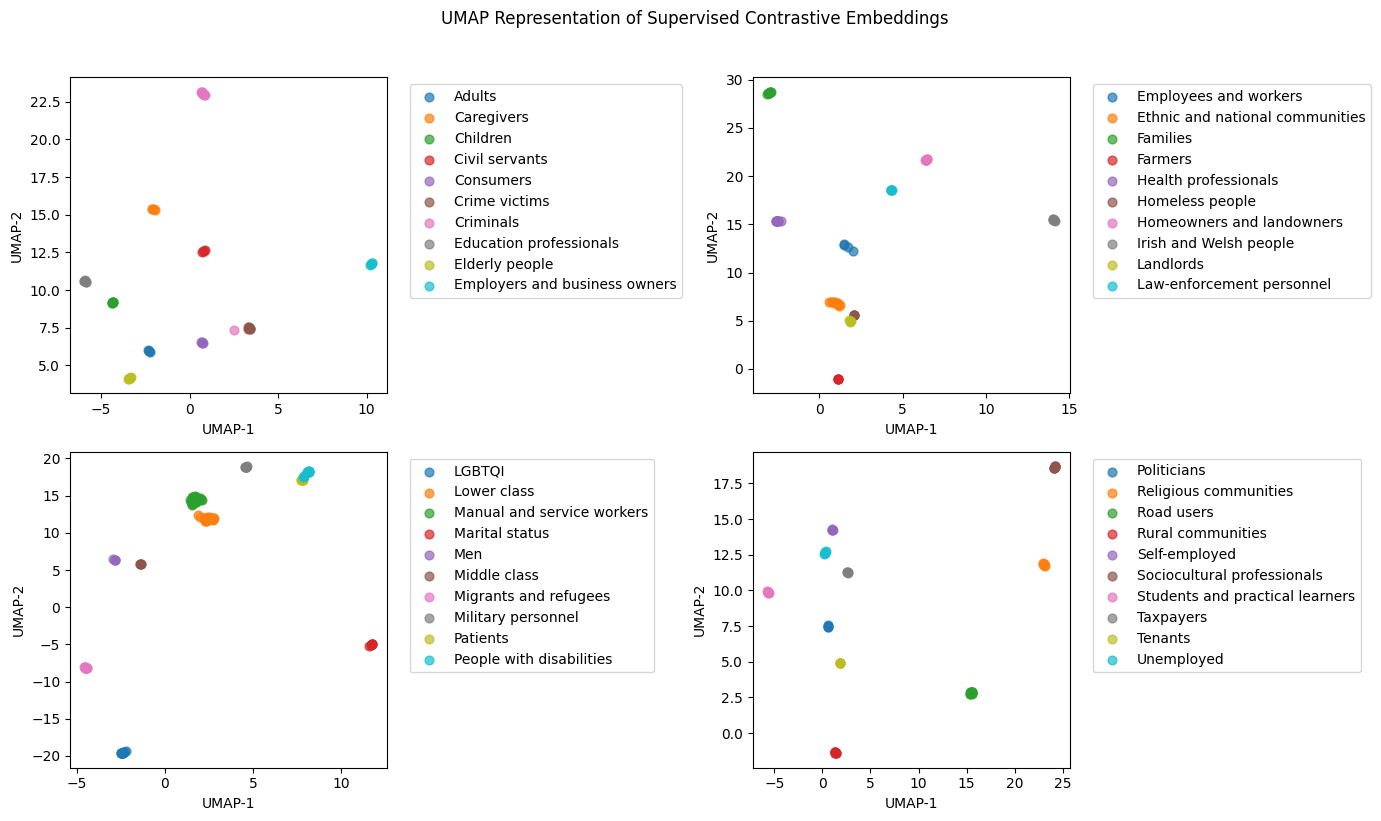

In [17]:
reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(mention_embeddings)

categories = list(cat2id.keys())
num_classes = len(categories)

groups = [
    range(0, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, group in zip(axes, groups):
    for c in group:
        if c >= num_classes:
            continue
        idx = np.where(labels_np == c)[0]
        if len(idx) == 0:
            continue
        ax.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            label=categories[c],
            alpha=0.7,
            s=40
        )
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

fig.suptitle("UMAP Representation of Supervised Contrastive Embeddings", y=1.02)
plt.tight_layout()
plt.show()

Original number of categories: 45
Best k by BIC: 42


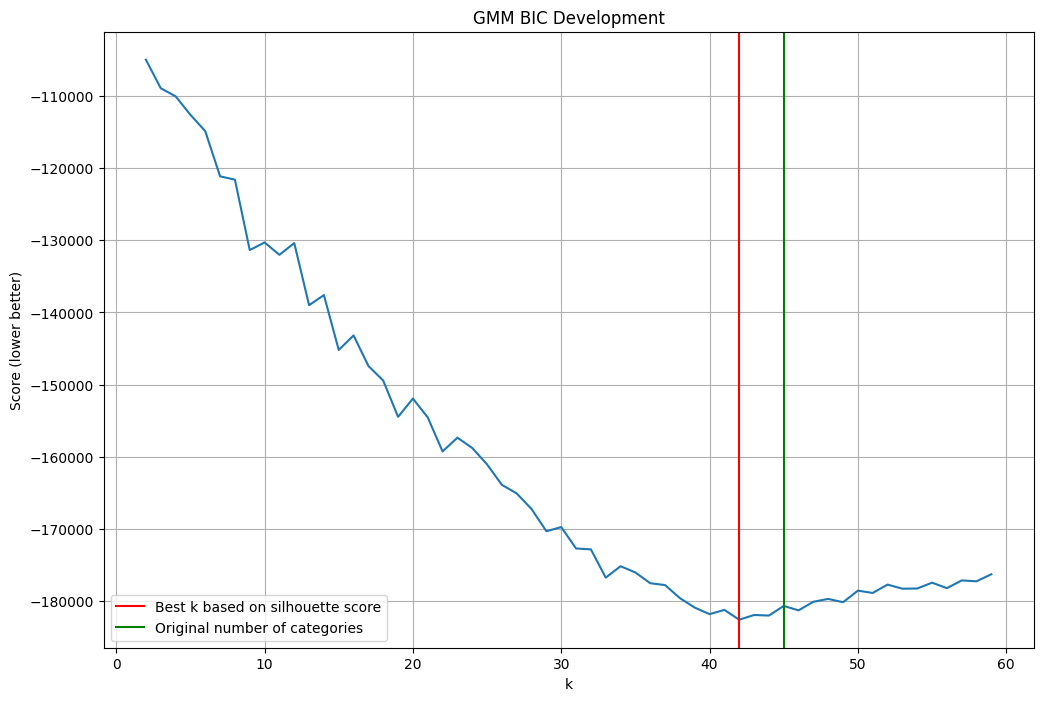

In [18]:
X = mention_embeddings.cpu().numpy()
pca = PCA(n_components=50, random_state=0)
X_red = pca.fit_transform(X)

X_for_eval = X

ks = range(2, 60)
bics = []
cov_type = 'diag'
for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=cov_type,
        random_state=7,
        n_init=5,
        reg_covar=1e-6,
        max_iter=500
    )
    gmm.fit(X_for_eval)
    bics.append(gmm.bic(X_for_eval))

bics = np.array(bics)
best_idx = bics.argmin()
best_k = ks[best_idx]
print("Original number of categories: 45")
print("Best k by BIC:", best_k)

plt.figure(figsize=(12,8))
plt.plot(list(ks), bics)
plt.axvline(best_k, color="red", label="Best k based on silhouette score")
plt.axvline(45, color="green", label="Original number of categories")
plt.xlabel('k')
plt.ylabel('Score (lower better)')
plt.title(f'GMM BIC Development')
plt.legend()
plt.grid(True)
plt.show()

Original number of categories: 45
Best k by silhouette score: 39


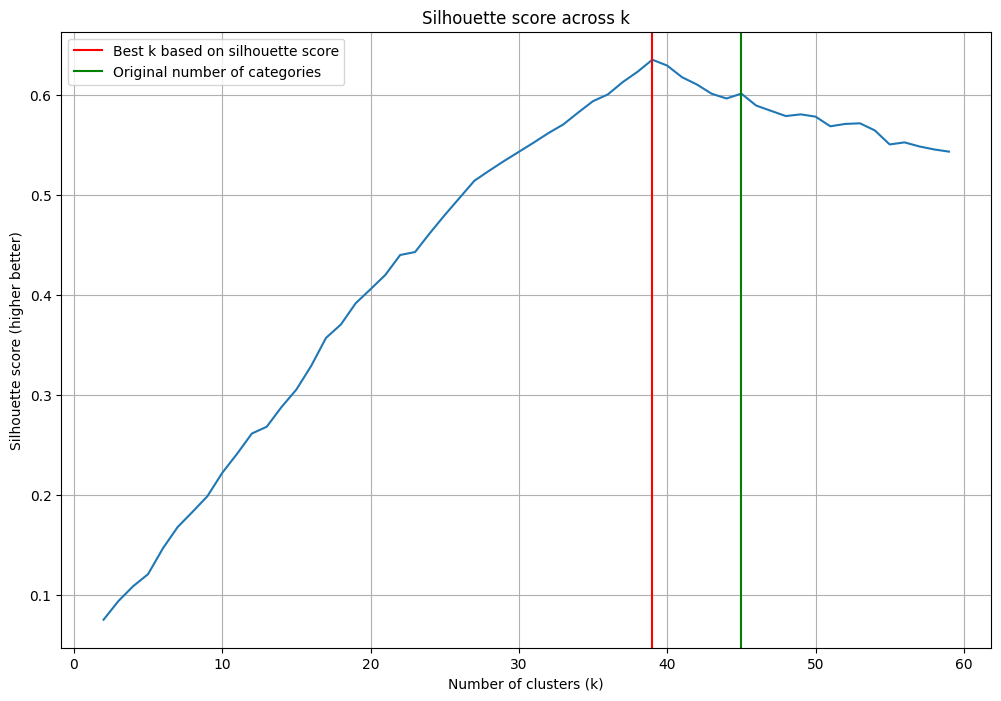

In [23]:
X = mention_embeddings.numpy()
#reducer = PCA(n_components=50, random_state=0)
reducer = umap.UMAP(n_components=2)
X_red = reducer.fit_transform(X)

X_for_eval = X

num_potential_clusters = 60

all_scores = []

for k in range(2, num_potential_clusters):
    kmeans = KMeans(n_clusters=k, random_state=7)
    #kmedoids = KMedoids(n_clusters=k, metric="euclidean")
    pred_labels = kmeans.fit_predict(X_for_eval)
    #pred_labels = kmedoids.fit_predict(X_for_eval)
    all_scores.append(silhouette_score(X_for_eval, pred_labels))

ks = list(range(2, num_potential_clusters))
scores = np.array(all_scores)

best_idx = scores.argmax()
best_k = ks[best_idx]
best_score = scores[best_idx]

print("Original number of categories: 45")
print(f"Best k by silhouette score: {best_k}")

plt.figure(figsize=(12, 8))
plt.plot(ks, scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (higher better)")
plt.title("Silhouette score across k")
plt.grid(True)
plt.axvline(best_k, color="red", label="Best k based on silhouette score")
plt.axvline(45, color="green", label="Original number of categories")
plt.legend()
plt.show()

In [14]:
X = mention_embeddings.numpy()
reducer = PCA(n_components=50, random_state=0)
#reducer = umap.UMAP(n_components=50)
X_red = reducer.fit_transform(X)

X_for_clustering = X

k = len(set(categories))
kmeans = KMeans(n_clusters=k, random_state=42)
#kmedoids = KMedoids(n_clusters=k, metric='euclidean', random_state=42)

cluster_labels = kmeans.fit_predict(X_for_clustering)
#cluster_labels = kmedoids.fit_predict(X_for_clustering)

cluster_labels = kmeans.labels_

df['cluster'] = cluster_labels

clusters = df['cluster'].unique()
cluster2cat = {c: df[df['cluster']==c]['category'].tolist() for c in clusters}
sorted_dict = dict(sorted(cluster2cat.items()))
sorted_dict

{0: ['LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI'],
 1: ['White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers'],
 2: ['Consumers', 'Consumers', 'Consumers', 'Consumers'],
 3: ['Criminals',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and national communities',
  'Lower class',
  'Upper class',
  'Upper class'],
 4: ['Manual and service workers',
  'Manual and service workers',
  'Manual and service workers',
  'Manual and service workers',
  'Manual and service workers

In [55]:
# import all mentions
with open("../01_data/annotations/annotations_no_augmentations.json") as f:
    all_annotations = json.load(f)

# get all individual group mentions
flat_mentions = [ann["text"] for task in all_annotations for ann in task["annotations"] if task["annotations"]]

# pass them through the model
all_embeddings = get_mask_embedding(model, flat_mentions, tokenizer, device)

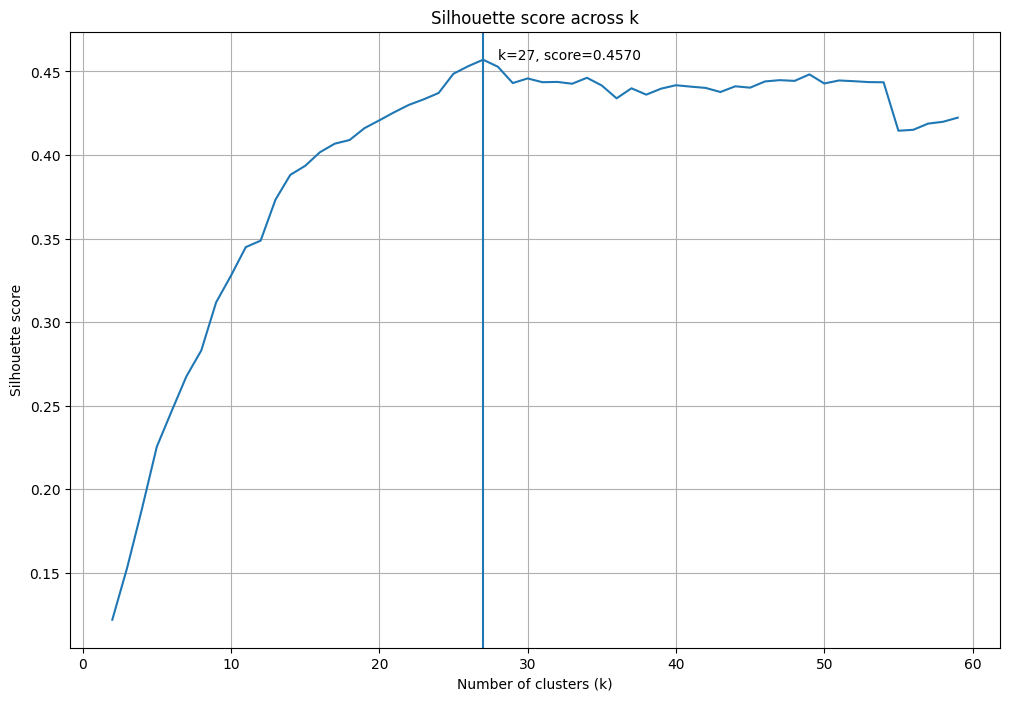

In [75]:
X = all_embeddings.numpy()

# reduce dimension further if wanted
reducer = PCA(n_components=50, random_state=0)
#reducer = umap.UMAP(n_components=10)
X_red = reducer.fit_transform(X)

X_for_eval = X

num_potential_clusters = 60

all_scores = []

for k in range(2, num_potential_clusters):
    kmeans = KMeans(n_clusters=k, random_state=7)
    pred_labels = kmeans.fit_predict(X_for_eval)
    all_scores.append(silhouette_score(X_for_eval, pred_labels))

ks = list(range(2, num_potential_clusters))
scores = np.array(all_scores)

best_idx = scores.argmax()
best_k = ks[best_idx]
best_score = scores[best_idx]

plt.figure(figsize=(12, 8))
plt.plot(ks, scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score across k")
plt.grid(True)
plt.axvline(best_k)
plt.annotate(
    f"k={best_k}, score={best_score:.4f}",
    xy=(best_k, best_score),
    xytext=(best_k + 1, best_score),
)
plt.show()

In [76]:
X = all_embeddings.numpy()
kmeans = KMeans(n_clusters=27, random_state=7)
labels = kmeans.fit_predict(X)
cluster_df = pd.DataFrame({"group mention": flat_mentions,
                           "cluster": labels})

clusters = cluster_df['cluster'].unique()
cluster2cat = {c: cluster_df[cluster_df['cluster']==c]['group mention'].tolist() for c in clusters}
sorted_dict = dict(sorted(cluster2cat.items()))
sorted_dict

{0: ['children',
  'every child',
  'child',
  'child',
  'child',
  'children',
  'disadvantaged children',
  'any child under the age of 18',
  'unaccompanied children from Calais',
  'every child',
  'the children and their families most in need',
  'the kids on the programme this year',
  'children',
  'those children who have special educational needs',
  'these children',
  'those children',
  'white children in custody',
  'children',
  'child',
  'child',
  'children from the poorest backgrounds',
  'children in the most disadvantaged parts',
  'children',
  'children',
  'children',
  'every child',
  'Children',
  'children in families',
  'child',
  'child',
  'children',
  'child',
  'childminders',
  'child',
  'child',
  'Children',
  'child',
  'Children',
  'every looked-after child',
  'children',
  'Children',
  'child',
  'children',
  'child',
  'young disadvantaged children',
  'child',
  'girls at risk',
  'child',
  'Child',
  'child',
  'children with special ed